In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Import libraries

from src.data.returns import * 
from src.dependence.dependence import cov_matrix

from src.dependence.copula_modelling import load_vine_model
from src.optimisation.hmv.clustering import clustering_matrix, plot_dendrogram
from src.optimisation.hmv.seriation import quasi_diagonalisation, plot_covariance_matrix

from src.optimisation.hmv.recursive_bisection import heuristic_optimisation, gamma_sweep, plot_gamma_sensitivity, gamma_sensitivity
from src.optimisation.mvp.mvp_solver import *

from src.performance.portfolio_metrics import portfolio_metrics, sub_period_metrics
from src.performance.portfolio_return_dataframe import portfolio_return_dataframe
from src.performance.rolling_weights import (
    plot_gamma_weights,
    plot_gamma_metrics,
    plot_individual_weights,
    rolling_weights,
    plot_rolling_weights,
    plot_turnover_comparison
)


In [ ]:
load_vine_model()

In [ ]:
train, test = split_returns();

In [ ]:
train.index.min()

In [ ]:
test.index.min()

In [ ]:
test.index.max()

In [ ]:
tickers = test.columns

In [ ]:
tickers

In [ ]:
test.head(5)

In [ ]:
test.tail(5)

In [ ]:
portfolio_returns = portfolio_return_dataframe(train_returns=train, test_returns=test)
portfolio_performance_metrics = portfolio_metrics(portfolio_returns)

table_perfomance = pd.DataFrame(
    {col: portfolio_metrics(portfolio_returns[col]) for col in portfolio_returns.columns}
).T

table_perfomance

In [ ]:
table2 = sub_period_metrics(portfolio_returns)
print(table2.to_string())

In [ ]:
gamma_sensitivity

In [ ]:
opt_results = gamma_sensitivity(train, test);

In [ ]:
opt_gamma, opt_sharpe = plot_gamma_sensitivity(opt_results)

In [ ]:
print(f'Optimal gamma = ', opt_gamma)
print(f'Optimal Sharpe ratio = ', opt_sharpe)

In [ ]:
# ── Cell: build comparison table ──────────────────────────────────────────
from src.optimisation.hmv.recursive_bisection import gamma_comparison
from src.performance.rolling_weights import (
    plot_sharpe_comparison,
    plot_dr_comparison,
    plot_gamma_weights
)

gamma_values = [0, 0.24, 0.5, 0.74, 0.88, 1]

comparison_df = gamma_comparison(
    opt_results   = opt_results,
    gamma_values  = gamma_values,
    train_returns = train,
    test_returns  = test
)

# summary table — weights column excluded for readability
print(comparison_df[['sharpe', 'diversification_ratio', 'type']].to_string())

In [ ]:
# ── Cell: three comparison figures ────────────────────────────────────────
plot_sharpe_comparison(comparison_df)
plot_dr_comparison(comparison_df)
plot_gamma_weights(comparison_df, top_n=15)

In [ ]:
# ── Cell: individual weight plots per strategy ────────────────────────────
plot_individual_weights(comparison_df, top_n=50)

In [ ]:
mvp_weights(train.cov())

In [ ]:
len(opt_results.iloc[0]['weights'])

In [ ]:
# Data descriptive analysis.

returns_df = get_log_returns()

In [ ]:
returns_df.head()

In [ ]:
desc_stats = descriptive_statistics(returns_df)
print(desc_stats.to_string())

In [ ]:
weight_dfs = rolling_weights(
    returns_df   = train,
    train_window = 504,          # 2-year training window
    refit_freq   = 63,           # refit every quarter
    gamma        = 0.88           # replace with optimal_gamma from Figure 3
)

Saved: C:\Users\masivuye.mpako\Blackbox\quants\portfolio-optimisation-copula-heuristic\data\output\results\figure4_rolling_weights.png


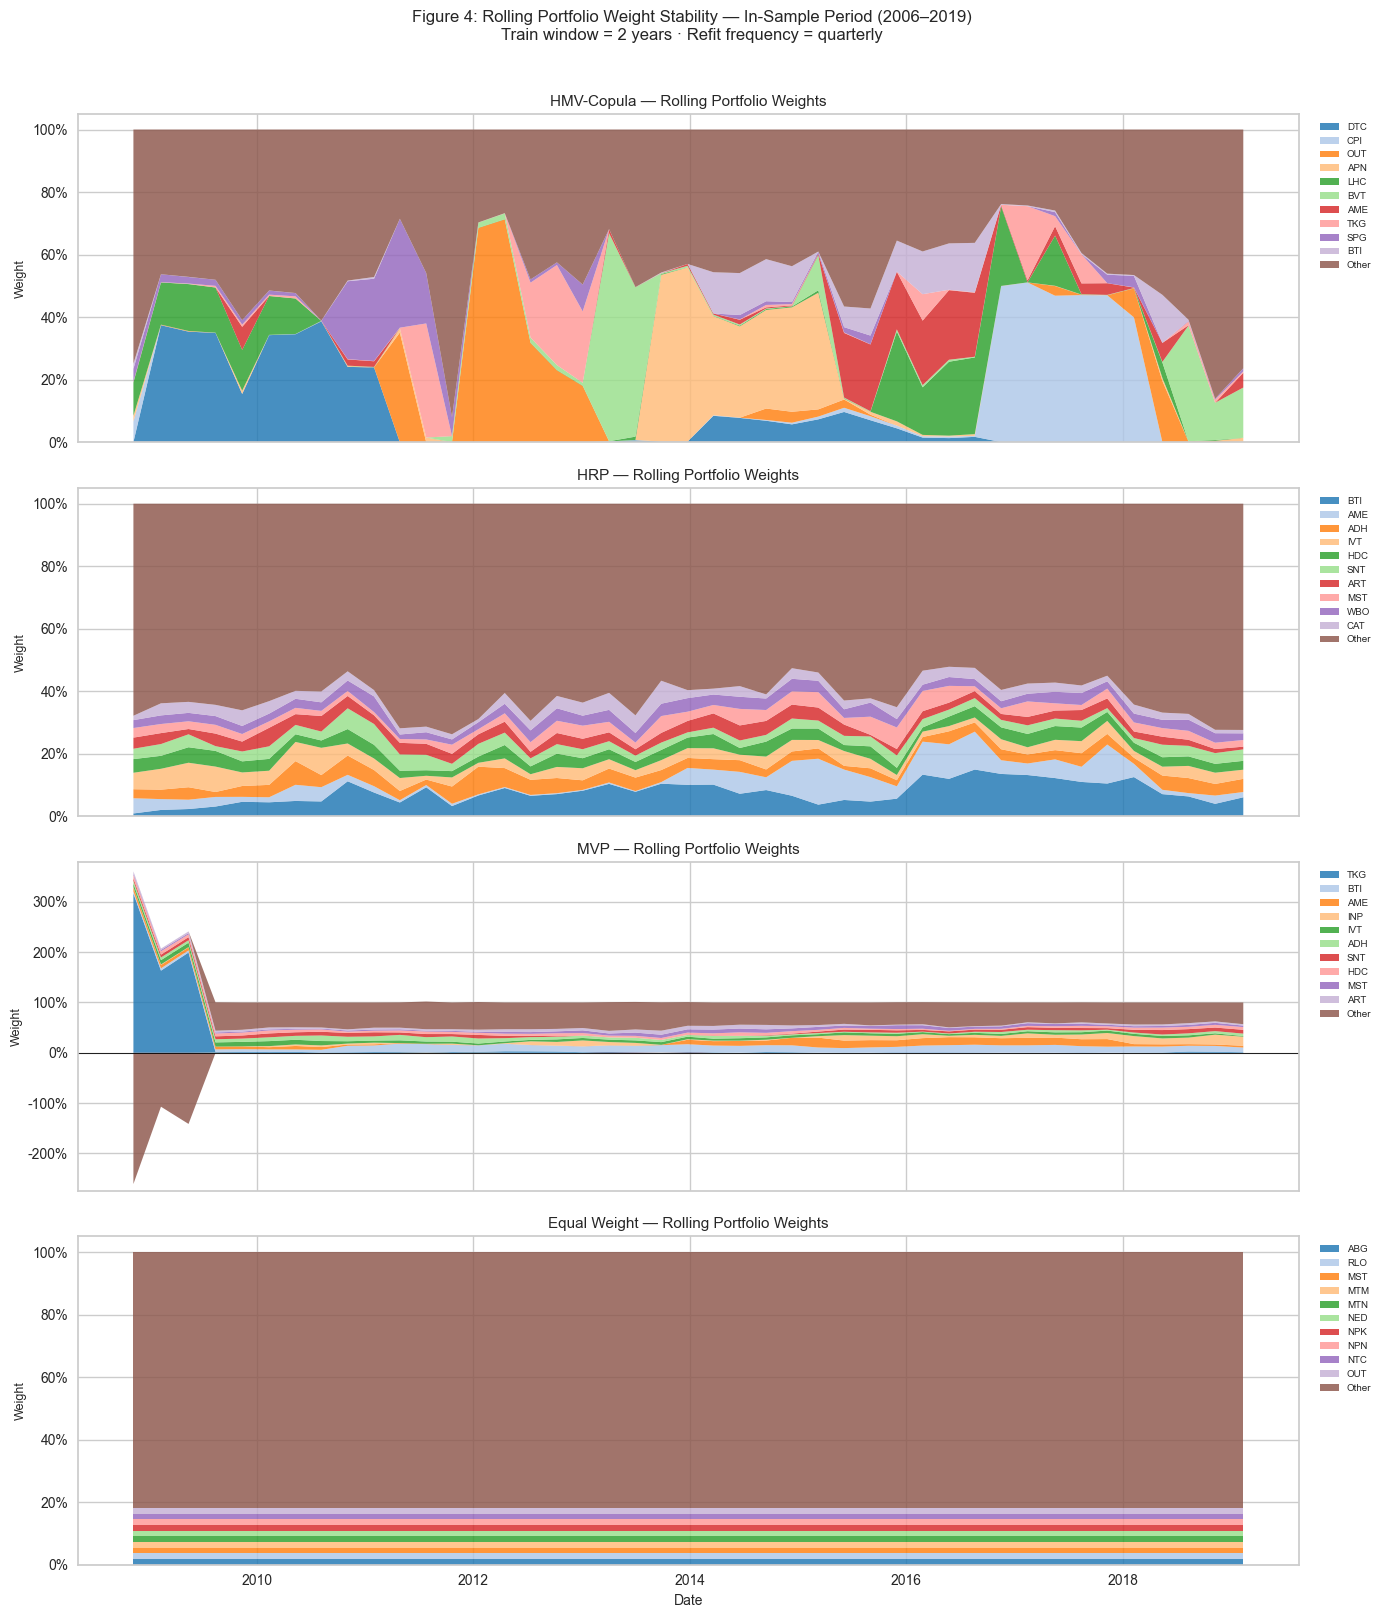

In [38]:
# Figure 4a — stacked area charts
plot_rolling_weights(weight_dfs, top_n=10)


In [ ]:
plot_turnover_comparison(weight_dfs)